This notebook shows the LCs obtained from the first test of the automated pipeline for generating the dataset. 1 LC per class was generated as described in Phase2.md

In [23]:
import os
import numpy as np
import pandas as pd

lightcurves_dir = "../data/lightcurves"

In [24]:
# find all .npy files in the lightcurves directory
npy_files = [f for f in os.listdir(lightcurves_dir) if f.endswith(".npy")]
print("\nFound .npy files:")
for f in npy_files:
    print(f"  - {f}")


Found .npy files:
  - 0000000000.npy
  - 0000000001.npy
  - 0000000003.npy
  - 0000000002.npy


In [25]:
metadata = pd.read_csv("../data/metadata.csv", delimiter=",", dtype=str)
metadata.head()

,file_id,label,activity_class,teff,logg,rotation_period_days,inclination_deg,sigma_ppm,tau_days,spot_enable,...,planet_present,planet_period_days,planet_radius_rjup,planet_radius_earth,planet_sma_au,transit_depth_ppm,seed,n_points,duration_days,snr_proxy
0,0000000001,1,strong,5865.5,4.222,15.76,58.22,165.83,2.347,1,...,0,NaN,NaN,NaN,NaN,NaN,1662057958,899517,266.9994212962963,26.999579482907624
1,0000000003,3,strong,5997.8,4.447,15.15,77.59,125.58,1.836,1,...,1,5.2648,0.08991,0.9890100000000001,0.05923,81.56726070014025,1008363426,899517,266.9994212962963,0.057259085528368704
2,0000000000,0,mild,5726.7,4.501,25.46,74.14,28.49,0.978,1,...,0,NaN,NaN,NaN,NaN,NaN,191664964,899517,266.9994212962963,27.737545982059572
3,0000000002,2,mild,5427.4,4.245,22.14,78.37,34.24,0.703,1,...,1,45.6322,0.13982,1.53802,0.24991,197.259749716561,163945743,899565,266.9994212962963,0.07037030125915143


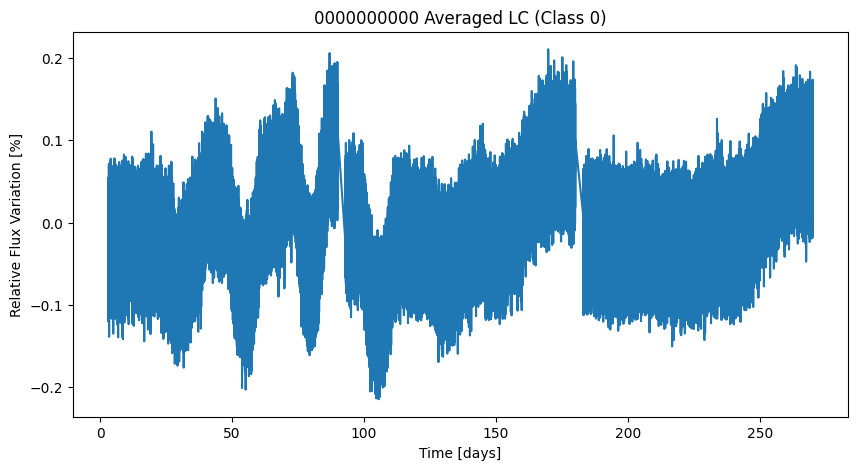

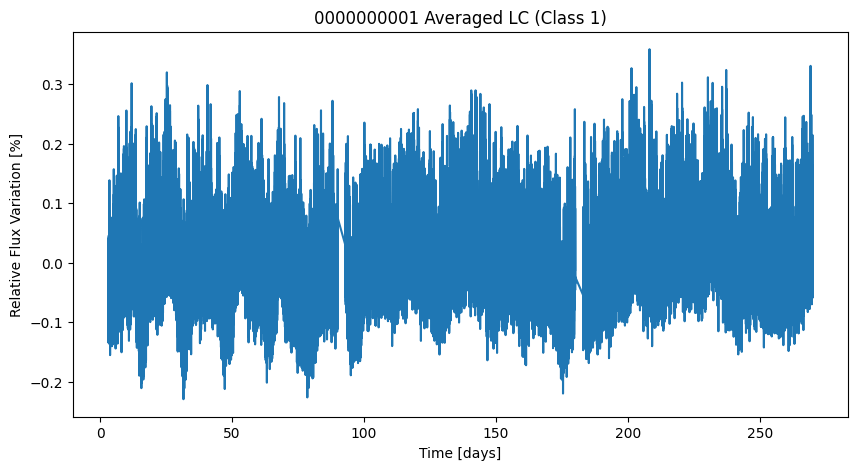

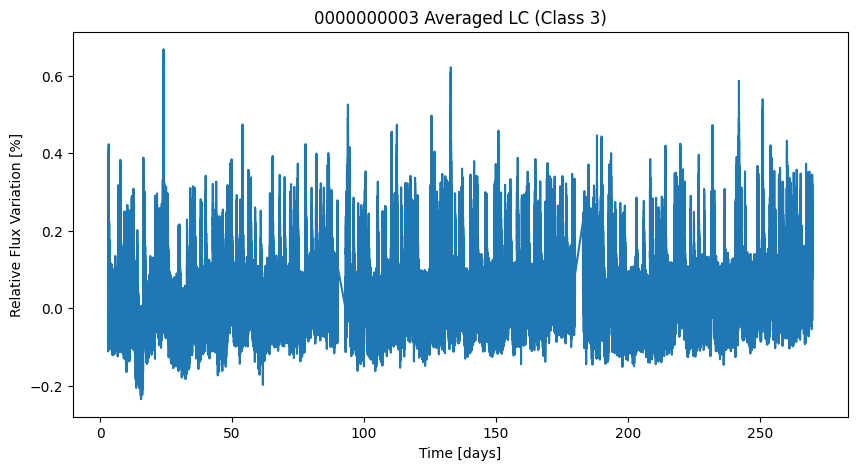

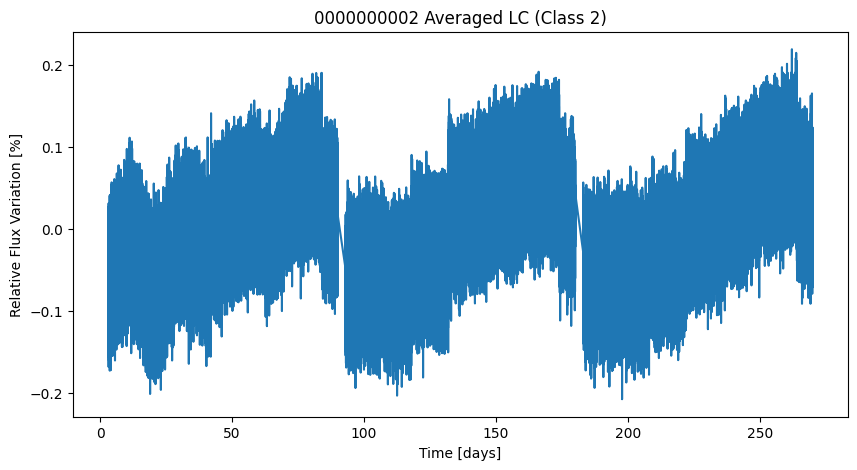

In [26]:
import matplotlib.pyplot as plt

for npy_file in npy_files:
    
    plt.figure(figsize=(10, 5))
    data = np.loadtxt(os.path.join(lightcurves_dir, npy_file),dtype=float)
    x = data[:, 0]
    y = data[:, 1]
    class_label = metadata.loc[metadata['file_id'] == npy_file.split(".")[0], 'label'].values[0]
    file_id = npy_file.split(".")[0]
    plt.plot(x, y)
    plt.xlabel("Time [days]")
    plt.ylabel("Relative Flux Variation [%]")
    plt.title(f"{file_id} Averaged LC (Class {class_label})")
    plt.show()
    plt.close()